## Imports

The next block imports the evaluation loop, model collection utilities, augmentation interfaces, dataset loader, and PyTorch components required to construct and evaluate the ensemble.


In [1]:
from vision_studio.evaluate import LoopEvaluator, ClassificationEvaluationMetrics
from vision_studio.models import (
    CollectionId,
    ModelSelection,
    WeightMode,
    select_model_collection,
    BaseModel
)
from vision_studio.reporting import WandbReporter, ReporterContext
from vision_studio.augmentation import (
    Augmentation,
    BrightnessNormalization,
    Compose,
    ContrastNormalization,
    EdgeSharpen,
    HistogramEqualization,
    Resize,
    SobelFilter,
)
from vision_studio.types import ClassificationPostprocessOutput, LossOutput, ClassificationEvaluatorOutput
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Any
from pathlib import Path
from vision_studio.dataset import ImageNetClassificationDataset
from vision_studio.models import InputSpec, OutputSpec
from vision_studio.data_loader import SimpleDataLoader


## Experiment configuration

The next block defines the GTSRB dataset location, determines the number of classes from the training folders, and selects CUDA when it is available.


In [2]:
DATASET_PATH = Path("/home/mozi30/data/datasets/gtsrb_out")
NUM_CLASSES = len([p for p in (DATASET_PATH / "train").iterdir() if p.is_dir()])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Custom model definition

The next block defines the custom CNN and transformer architecture used by the selected CustomModel checkpoints. It also implements the common `BaseModel` interfaces needed by the evaluator.


In [3]:
class GlobalTransformerBlock(nn.Module):
    def __init__(self, channels: int, heads: int = 4, layers: int = 1):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=heads,
            dim_feedforward=channels * 2,
            dropout=0.1,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
        )

    def forward(self, x):
        # x: (B, C, H, W)
        B, C, H, W = x.shape

        tokens = x.flatten(2).transpose(1, 2)   # (B, H*W, C)
        tokens = self.transformer(tokens)
        x = tokens.transpose(1, 2).view(B, C, H, W)

        return x


class CustomModel(BaseModel):
    def __init__(self, input_shape: tuple, num_classes: int):
        super().__init__()

        self.num_classes = num_classes

        self.features = nn.Sequential(
            # 224 -> 112
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 112 -> 56
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 56 -> 28
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 28 -> 14
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.global_attn = GlobalTransformerBlock(
            channels=128,
            heads=4,
            layers=1,
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        self.lossIsWeighted = False

    @property
    def input_spec(self) -> InputSpec:
        return InputSpec(dtype=torch.float32)

    @property
    def output_spec(self) -> OutputSpec:
        return OutputSpec(dtype=torch.float32)

    def forward(self, inputs):
        x = self.features(inputs)      # (B, 128, 14, 14) for 224x224
        x = self.global_attn(x)        # global attention over 196 tokens
        logits = self.classifier(x)
        return logits

    def postprocess(self, logits) -> ClassificationPostprocessOutput:
        probs = torch.softmax(logits, dim=1)
        labels = torch.argmax(logits, dim=1)

        return ClassificationPostprocessOutput(
            logits=logits,
            probs=probs,
            labels=labels,
        )
    
    def set_loss_weights(self, class_weights: torch.Tensor):
        """Set class weights for the loss function."""
        self.lossIsWeighted = True
        self.class_weights = class_weights

    def compute_loss(self, logits, targets) -> LossOutput:
        labels = targets["label"]
        if self.lossIsWeighted:
            loss = F.cross_entropy(logits, labels, weight=self.class_weights.to(logits.device))
        else:
            loss = F.cross_entropy(logits, labels)
        return LossOutput(loss=loss)

## Torchvision model wrappers

The next block wraps ResNet50 and SwinV2-T as Vision Studio models. These wrappers replace the classification heads and provide consistent postprocessing and loss computation for ensemble evaluation.


In [4]:
class ResNet50(BaseModel):
    def __init__(self,model : Any, num_classes: int, device: str):
        super().__init__()
        self.num_classes = num_classes
        self.model = model
        model_in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(model_in_features, num_classes)
        self.model.to(device)
        self.lossIsWeighted = False

    @property
    def input_spec(self) -> InputSpec:
        """Expected input specification."""
        return InputSpec(dtype=torch.float32)

    @property
    def output_spec(self) -> OutputSpec:
        """Output specification for forward()."""
        return OutputSpec(dtype=torch.float32)

    def forward(self, inputs):
        """Return ONLY logits for speed."""
        logits = self.model(inputs)
        return logits

    def postprocess(self, logits) -> ClassificationPostprocessOutput:
        """Task-specific postprocessing for classification."""
        probs = torch.softmax(logits, dim=1)
        labels = torch.argmax(logits, dim=1)

        return ClassificationPostprocessOutput(
            logits=logits,
            probs=probs,
            labels=labels,
        )

    def set_loss_weights(self, class_weights: torch.Tensor):
        """Set class weights for the loss function."""
        self.lossIsWeighted = True
        self.class_weights = class_weights

    def compute_loss(self, logits, targets) -> LossOutput:
        labels = targets["label"]
        if self.lossIsWeighted:
            loss = F.cross_entropy(logits, labels, weight=self.class_weights.to(logits.device))
        else:
            loss = F.cross_entropy(logits, labels)
        return LossOutput(loss=loss)





class SwinV2T(BaseModel):
    def __init__(self,model : Any, num_classes: int, device: str):
        super().__init__()
        self.num_classes = num_classes
        self.model = model
        model_in_features = self.model.head.in_features
        self.model.head = nn.Linear(model_in_features, num_classes)
        self.model.to(device)
        self.lossIsWeighted = False

    @property
    def input_spec(self) -> InputSpec:
        """Expected input specification."""
        return InputSpec(dtype=torch.float32)

    @property
    def output_spec(self) -> OutputSpec:
        """Output specification for forward()."""
        return OutputSpec(dtype=torch.float32)

    def forward(self, inputs):
        """Return ONLY logits for speed."""
        logits = self.model(inputs)
        return logits

    def postprocess(self, logits) -> ClassificationPostprocessOutput:
        """Task-specific postprocessing for classification."""
        probs = torch.softmax(logits, dim=1)
        labels = torch.argmax(logits, dim=1)

        return ClassificationPostprocessOutput(
            logits=logits,
            probs=probs,
            labels=labels,
        )

    def set_loss_weights(self, class_weights: torch.Tensor):
        """Set class weights for the loss function."""
        self.lossIsWeighted = True
        self.class_weights = class_weights

    def compute_loss(self, logits, targets) -> LossOutput:
        labels = targets["label"]
        if self.lossIsWeighted:
            loss = F.cross_entropy(logits, labels, weight=self.class_weights.to(logits.device))
        else:
            loss = F.cross_entropy(logits, labels)
        return LossOutput(loss=loss)



## Preprocessing and model selection

The next block defines the preprocessing transformations, loads the curated top three checkpoints for each architecture, and records their validation accuracies for weighted aggregation. Each selected model uses a distinct preprocessing or training strategy to encourage ensemble diversity.


In [5]:
class BoostTrafficSignColors(Augmentation):
    """Boost red, blue, and yellow traffic-sign colors."""

    def __init__(self, saturation_gain: float = 1.4, value_gain: float = 1.05, p: float = 1.0):
        super().__init__(p=p)
        self.saturation_gain = saturation_gain
        self.value_gain = value_gain

    def __call__(self, image: np.ndarray, target: dict[str, Any]):
        hsv = cv2.cvtColor(image.copy(), cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)
        red = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        red |= cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        blue = cv2.inRange(hsv, np.array([90, 100, 100]), np.array([130, 255, 255]))
        yellow = cv2.inRange(hsv, np.array([15, 100, 100]), np.array([35, 255, 255]))
        mask = (red | blue | yellow) > 0
        s = s.astype(np.float32)
        v = v.astype(np.float32)
        s[mask] *= self.saturation_gain
        v[mask] *= self.value_gain
        boosted = cv2.merge([h, np.clip(s, 0, 255).astype(np.uint8), np.clip(v, 0, 255).astype(np.uint8)])
        return cv2.cvtColor(boosted, cv2.COLOR_HSV2RGB).astype(image.dtype), target


resize = Resize(224, 224)
sobel = Compose([Resize(224, 224), SobelFilter()])
hist_eqal = Compose([Resize(224, 224), HistogramEqualization()])
normalisation = Compose([
    Resize(224, 224),
    ContrastNormalization(),
    BrightnessNormalization(),
])
traffic_sign_boost = Compose([
    Resize(224, 224),
    EdgeSharpen(strength=2, sigma=14.0),
    BrightnessNormalization(),
    ContrastNormalization(),
    BoostTrafficSignColors(saturation_gain=1.2, value_gain=1.02),
])
strengthen_edges = Compose([Resize(224, 224), EdgeSharpen(strength=2, sigma=7.0)])

MODEL_DIR = Path("/home/mozi30/data/models")


def load_resnet50(checkpoint_name: str) -> ResNet50:
    result = select_model_collection(
        ModelSelection(
            collection_id=CollectionId.TORCHVISION,
            model_id="resnet50",
            weight_mode=WeightMode.NONE,
        )
    )
    model = ResNet50(model=result.model, num_classes=NUM_CLASSES, device=DEVICE)
    model.load_checkpoint(MODEL_DIR / checkpoint_name, map_location=DEVICE)
    return model


def load_swin_v2_t(checkpoint_name: str) -> SwinV2T:
    result = select_model_collection(
        ModelSelection(
            collection_id=CollectionId.TORCHVISION,
            model_id="swin_v2_t",
            weight_mode=WeightMode.NONE,
        )
    )
    model = SwinV2T(model=result.model, num_classes=NUM_CLASSES, device=DEVICE)
    model.load_checkpoint(MODEL_DIR / checkpoint_name, map_location=DEVICE)
    return model


def load_custom_model(checkpoint_name: str) -> CustomModel:
    model = CustomModel(input_shape=(3, 224, 224), num_classes=NUM_CLASSES).to(DEVICE)
    model.load_checkpoint(MODEL_DIR / checkpoint_name, map_location=DEVICE)
    return model


# Top three checkpoints per architecture, selected from results_summary.csv.
best_model_specs = {
    "resnet_hist_eqal": {
        "architecture": "resnet",
        "label": "ResNet50 Histogram Equalization",
        "checkpoint": "resnet50-sgd-finetune-hist_eqal.pth",
        "augmentation": hist_eqal,
        "weight": 0.9900237321853638,
    },
    "resnet_traffic_boost": {
        "architecture": "resnet",
        "label": "ResNet50 Traffic Sign Boost",
        "checkpoint": "resnet50-sgd-finetune-traffic_boost.pth",
        "augmentation": traffic_sign_boost,
        "weight": 0.9885193705558777,
    },
    "resnet_edge_boost": {
        "architecture": "resnet",
        "label": "ResNet50 Edge Sharpening",
        "checkpoint": "resnet50-sgd-finetune-edge_boost_str_2_sig_7_0.pth",
        "augmentation": strengthen_edges,
        "weight": 0.9889944791793823,
    },
    "swin_base": {
        "architecture": "swin",
        "label": "SwinV2-T Base",
        "checkpoint": "swintransformer-base.pth",
        "augmentation": None,
        "weight": 0.9842438697814941,
    },
    "swin_hist_eqal": {
        "architecture": "swin",
        "label": "SwinV2-T Histogram Equalization",
        "checkpoint": "swintransformer-hist_eqal.pth",
        "augmentation": hist_eqal,
        "weight": 0.9834520816802979,
    },
    "swin_traffic_boost": {
        "architecture": "swin",
        "label": "SwinV2-T Traffic Sign Boost",
        "checkpoint": "swintransformer-traffic_boost.pth",
        "augmentation": traffic_sign_boost,
        "weight": 0.98210608959198,
    },
    "custom_weighted_balanced": {
        "architecture": "custom",
        "label": "CustomModel Weighted Loss Augmented Balanced",
        "checkpoint": "myModel-weighted-loss-augmented-balanced-finetune.pth",
        "augmentation": None,
        "weight": 0.9760887026786804,
    },
    "custom_base": {
        "architecture": "custom",
        "label": "CustomModel Base",
        "checkpoint": "myModel-finetune-base.pth",
        "augmentation": None,
        "weight": 0.9692794680595398,
    },
    "custom_hist_eqal": {
        "architecture": "custom",
        "label": "CustomModel Histogram Equalization",
        "checkpoint": "myModel-sgd-finetune-hist_eqal.pth",
        "augmentation": hist_eqal,
        "weight": 0.971179723739624,
    },
}

best_models = {}
for model_key, spec in best_model_specs.items():
    if spec["architecture"] == "resnet":
        best_models[model_key] = load_resnet50(spec["checkpoint"])
    elif spec["architecture"] == "swin":
        best_models[model_key] = load_swin_v2_t(spec["checkpoint"])
    else:
        best_models[model_key] = load_custom_model(spec["checkpoint"])

print(f"Loaded {len(best_models)} curated best models")

Loaded 9 curated best models


/tmp/ipykernel_1226018/683777753.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## Validation dataset

The next block creates one shared validation dataloader using the base resize transformation. Model-specific preprocessing is applied later by each ensemble member, so every model is evaluated on the same underlying samples.


In [6]:
dataset_val = ImageNetClassificationDataset(root_dir=str(DATASET_PATH), split="val", transform=resize)
assert dataset_val.get_num_classes() == NUM_CLASSES
dataloader = SimpleDataLoader(dataset_val, batch_size=32, shuffle=False)
print(f"Validation samples: {len(dataset_val)}; batches: {len(dataloader)}")


Validation samples: 12630; batches: 395


## Ensemble members

The next block combines each loaded model with its matching optional augmentation using `EnsembleMember`. This allows models with different preprocessing requirements to participate in a single evaluation loop.


In [7]:
from vision_studio.evaluate import EnsembleMember
from vision_studio.inference.simple import EnsembleConfig

ensemble_members = {
    model_key: EnsembleMember(
        model=best_models[model_key],
        augmentation=spec["augmentation"],
        name=spec["label"],
    )
    for model_key, spec in best_model_specs.items()
}

print("Available ensemble members:", list(ensemble_members))


Available ensemble members: ['resnet_hist_eqal', 'resnet_traffic_boost', 'resnet_edge_boost', 'swin_base', 'swin_hist_eqal', 'swin_traffic_boost', 'custom_weighted_balanced', 'custom_base', 'custom_hist_eqal']


## Visualisation of curated best-model ensemble results

This section evaluates nine curated models: the top three ResNet50, SwinV2-T, and CustomModel checkpoints from `results_summary.csv`. It compares each architecture trio, the best checkpoint from each architecture, and all nine models using soft, hard, and accuracy-weighted aggregation.


In [8]:
from vision_studio.evaluate import ClassificationEvaluationPerClassMetrics

# Replace these numeric labels with readable class names when available.
ensemble_class_names = [str(index) for index in range(NUM_CLASSES)]

resnet_best_three = [
    ensemble_members["resnet_hist_eqal"],
    ensemble_members["resnet_edge_boost"],
    ensemble_members["resnet_traffic_boost"],
]
swin_best_three = [
    ensemble_members["swin_base"],
    ensemble_members["swin_hist_eqal"],
    ensemble_members["swin_traffic_boost"],
]
custom_best_three = [
    ensemble_members["custom_weighted_balanced"],
    ensemble_members["custom_hist_eqal"],
    ensemble_members["custom_base"],
]
best_of_each_architecture = [
    ensemble_members["resnet_hist_eqal"],
    ensemble_members["swin_base"],
    ensemble_members["custom_weighted_balanced"],
]
all_nine_models = resnet_best_three + swin_best_three + custom_best_three

ensemble_groups = {
    "ResNet50 Best Three": resnet_best_three,
    "SwinV2-T Best Three": swin_best_three,
    "CustomModel Best Three": custom_best_three,
    "Best of Each Architecture": best_of_each_architecture,
    "All Nine Models": all_nine_models,
}


def member_accuracy_weights(members):
    weights_by_name = {spec["label"]: spec["weight"] for spec in best_model_specs.values()}
    return [weights_by_name[member.name] for member in members]


ensemble_definitions = {}
for group_name, members in ensemble_groups.items():
    ensemble_definitions[f"Soft: {group_name}"] = {
        "models": members,
        "config": EnsembleConfig(mode="soft"),
        "evaluation_type": group_name,
    }
    ensemble_definitions[f"Hard: {group_name}"] = {
        "models": members,
        "config": EnsembleConfig(mode="hard"),
        "evaluation_type": group_name,
    }
    ensemble_definitions[f"Weighted: {group_name}"] = {
        "models": members,
        "config": EnsembleConfig(mode="weighted", weights=member_accuracy_weights(members)),
        "evaluation_type": group_name,
    }

# Set this to a list of names when you only want to rerun selected evaluations.
EVALUATIONS_TO_RUN = None
if EVALUATIONS_TO_RUN is not None:
    ensemble_definitions = {
        name: definition
        for name, definition in ensemble_definitions.items()
        if name in EVALUATIONS_TO_RUN
    }

ensemble_results = {}
for ensemble_name, definition in ensemble_definitions.items():
    print(f"Evaluating {ensemble_name}...")
    visualisation_metrics = ClassificationEvaluationPerClassMetrics(
        num_classes=NUM_CLASSES,
        class_names=ensemble_class_names,
    )
    visualisation_evaluator = LoopEvaluator(
        metrics=visualisation_metrics,
        device=DEVICE,
    )
    result = visualisation_evaluator.evaluate_ensemble(
        models=definition["models"],
        dataset=dataloader,
        config=definition["config"],
    )
    result["evaluation_type"] = definition["evaluation_type"]
    result["member_names"] = [member.name for member in definition["models"]]
    ensemble_results[ensemble_name] = result

print(f"Evaluated {len(ensemble_results)} curated ensemble configurations")


Evaluating Soft: ResNet50 Best Three...
Evaluating Hard: ResNet50 Best Three...
Evaluating Weighted: ResNet50 Best Three...
Evaluating Soft: SwinV2-T Best Three...
Evaluating Hard: SwinV2-T Best Three...
Evaluating Weighted: SwinV2-T Best Three...
Evaluating Soft: CustomModel Best Three...
Evaluating Hard: CustomModel Best Three...
Evaluating Weighted: CustomModel Best Three...
Evaluating Soft: Best of Each Architecture...
Evaluating Hard: Best of Each Architecture...
Evaluating Weighted: Best of Each Architecture...
Evaluating Soft: All Nine Models...
Evaluating Hard: All Nine Models...
Evaluating Weighted: All Nine Models...
Evaluated 15 curated ensemble configurations


## Result visualisation

The next block converts the ensemble results into a summary table and comparison charts. It also prepares confusion matrices and per-class precision, recall, and F1 visualisations for detailed analysis.


,ensemble,accuracy,f1_macro,precision_macro,recall_macro,loss,status,mode,evaluation_type,members
0,Soft: ResNet50 Best Three,0.995249,0.992900,0.993755,0.992462,0.043641,completed,soft,ResNet50 Best Three,"ResNet50 Histogram Equalization, ResNet50 Edge..."
1,Hard: ResNet50 Best Three,0.992716,0.989452,0.989689,0.989737,0.043641,completed,hard,ResNet50 Best Three,"ResNet50 Histogram Equalization, ResNet50 Edge..."
2,Weighted: ResNet50 Best Three,0.995249,0.992900,0.993755,0.992462,0.043641,completed,weighted,ResNet50 Best Three,"ResNet50 Histogram Equalization, ResNet50 Edge..."
3,Soft: SwinV2-T Best Three,0.990024,0.985335,0.987510,0.984296,0.077981,completed,soft,SwinV2-T Best Three,"SwinV2-T Base, SwinV2-T Histogram Equalization..."
4,Hard: SwinV2-T Best Three,0.989232,0.985050,0.987097,0.983818,0.077981,completed,hard,SwinV2-T Best Three,"SwinV2-T Base, SwinV2-T Histogram Equalization..."
5,Weighted: SwinV2-T Best Three,0.990024,0.985335,0.987510,0.984296,0.077981,completed,weighted,SwinV2-T Best Three,"SwinV2-T Base, SwinV2-T Histogram Equalization..."
6,Soft: CustomModel Best Three,0.990024,0.985669,0.986874,0.984973,0.144795,completed,soft,CustomModel Best Three,"CustomModel Weighted Loss Augmented Balanced, ..."
7,Hard: CustomModel Best Three,0.986698,0.979563,0.978034,0.981960,0.144795,completed,hard,CustomModel Best Three,"CustomModel Weighted Loss Augmented Balanced, ..."
8,Weighted: CustomModel Best Three,0.990024,0.985672,0.986882,0.984973,0.144795,completed,weighted,CustomModel Best Three,"CustomModel Weighted Loss Augmented Balanced, ..."
9,Soft: Best of Each Architecture,0.993666,0.991262,0.991737,0.991288,0.080558,completed,soft,Best of Each Architecture,"ResNet50 Histogram Equalization, SwinV2-T Base..."


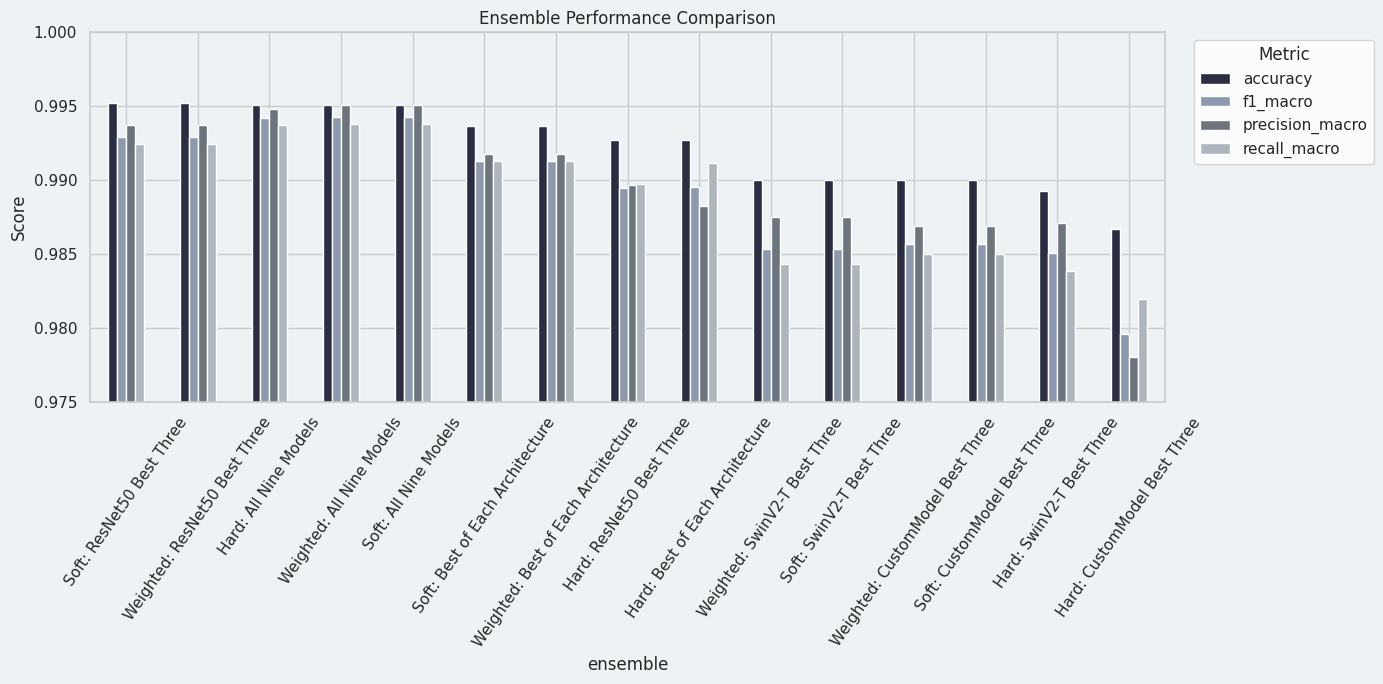

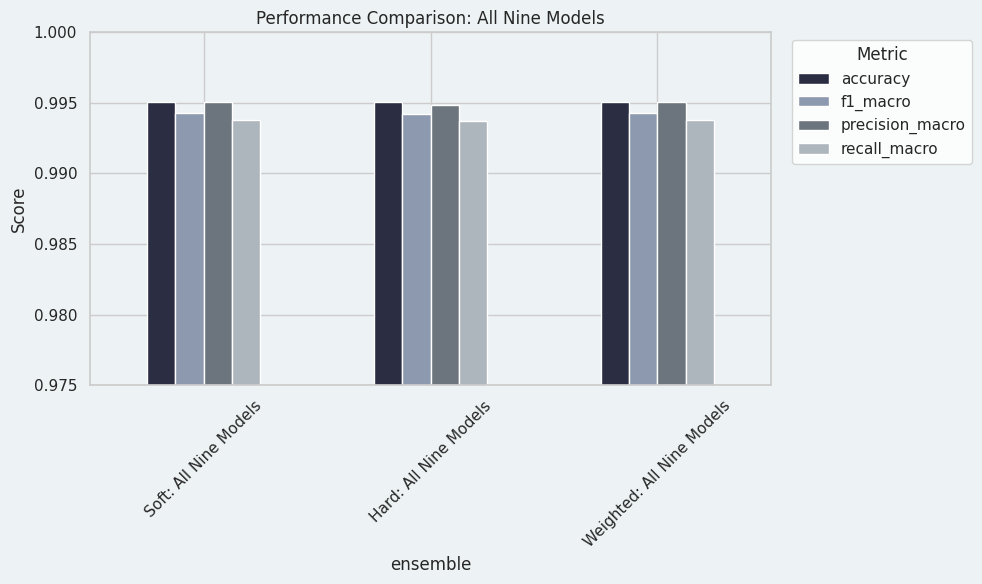

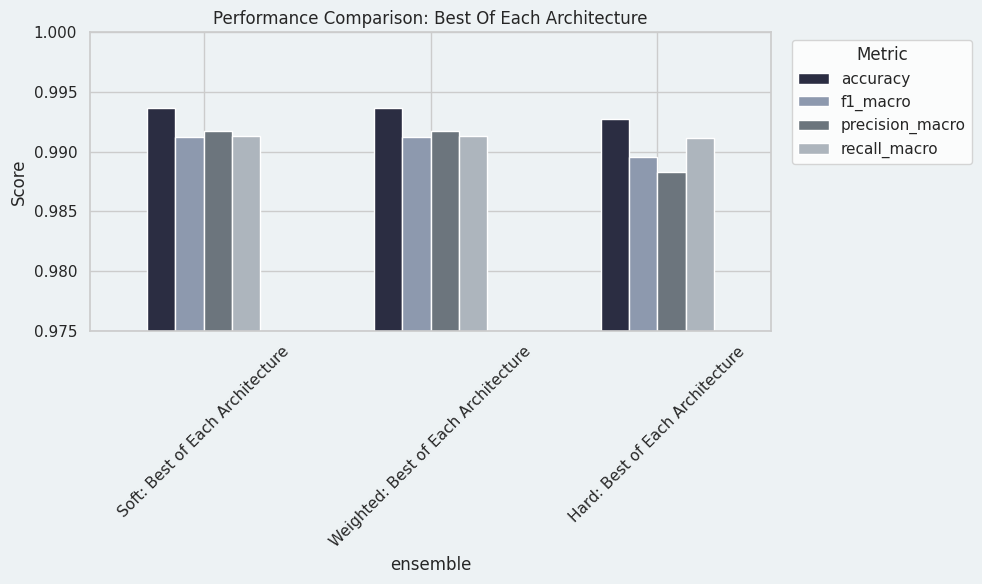

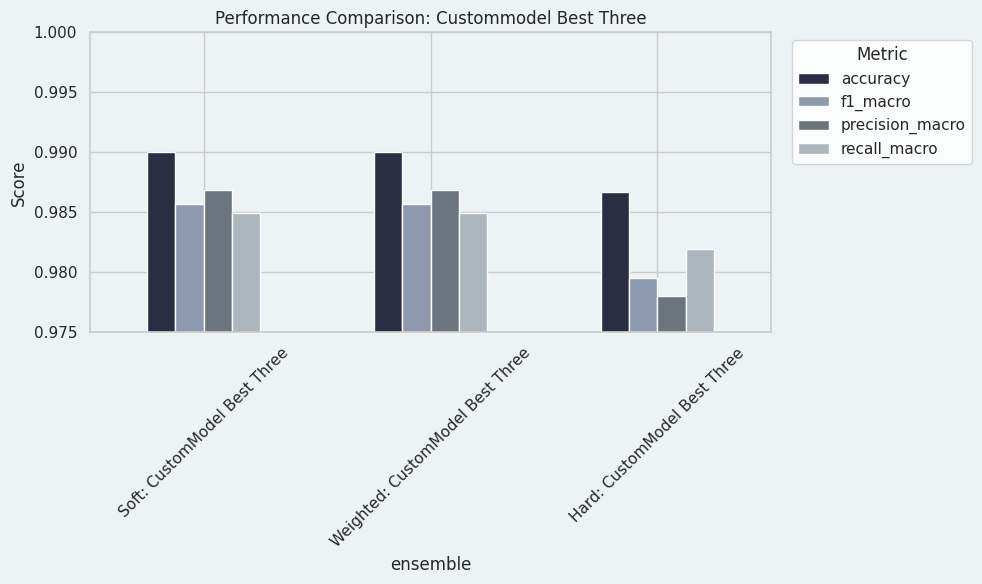

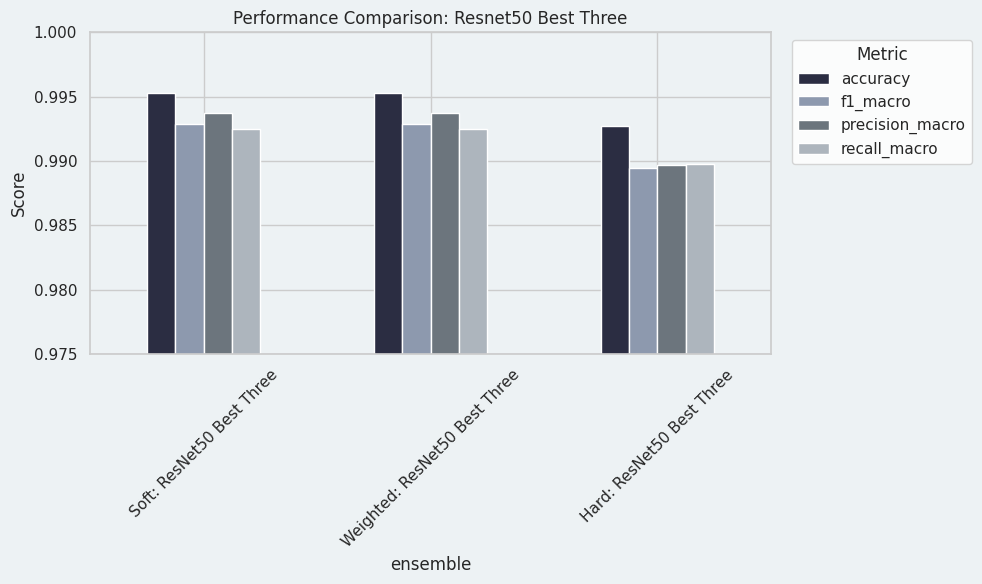

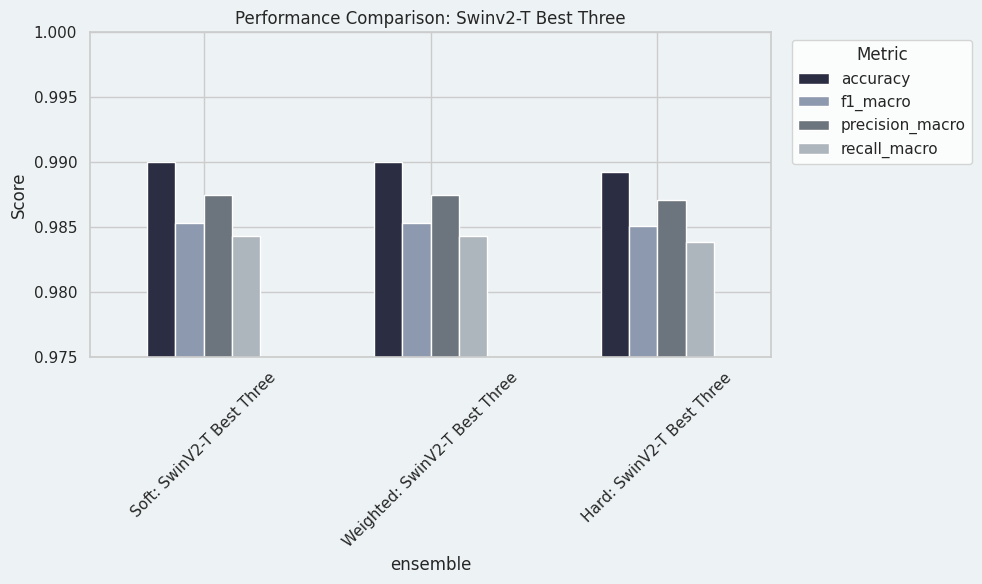

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PLOT_INLINE = True  # Set to False to save PNGs without displaying them.
ENSEMBLE_PLOT_DIR = Path("/home/mozi30/repos/private/CV_VisionStudio/notebooks/plots/ensemble")
ENSEMBLE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

SPACE_INDIGO = "#2b2d42"
LAVENDER_GREY = "#8d99ae"
PLATINUM = "#edf2f4"
sns.set_theme(style="whitegrid")

def finish_ensemble_plot(fig, filename):
    fig.tight_layout()
    if PLOT_INLINE:
        plt.show()
    else:
        path = ENSEMBLE_PLOT_DIR / filename
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {path}")

summary_rows = []
for ensemble_name, result in ensemble_results.items():
    confusion_matrix = result["confusion_matrix"].detach().cpu().numpy()
    total = confusion_matrix.sum()
    accuracy = float(np.trace(confusion_matrix) / total) if total else 0.0
    summary_rows.append(
        {
            "ensemble": ensemble_name,
            "accuracy": accuracy,
            "f1_macro": float(np.mean(result["f1_per_class"])),
            "precision_macro": float(np.mean(result["precision_per_class"])),
            "recall_macro": float(np.mean(result["recall_per_class"])),
            "loss": float(result["loss"]),
            "status": result["status"],
            "mode": result["aggregation_metadata"]["mode"],
            "evaluation_type": result["evaluation_type"],
            "members": ", ".join(result["member_names"]),
        }
    )

ensemble_summary_df = pd.DataFrame(summary_rows)
display(ensemble_summary_df)
ensemble_summary_df.to_csv(ENSEMBLE_PLOT_DIR / "ensemble_results_summary.csv", index=False)

if not ensemble_summary_df.empty:
    metric_columns = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
    plot_df = ensemble_summary_df.sort_values("accuracy", ascending=False).set_index("ensemble")[metric_columns]
    fig, ax = plt.subplots(figsize=(max(14, len(plot_df) * 0.55), 7))
    fig.patch.set_facecolor(PLATINUM)
    ax.set_facecolor(PLATINUM)
    plot_df.plot(kind="bar", ax=ax, color=[SPACE_INDIGO, LAVENDER_GREY, "#6c757d", "#adb5bd"])
    ax.set_title("Ensemble Performance Comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(0.975, 1)
    ax.tick_params(axis="x", rotation=55)
    ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
    finish_ensemble_plot(fig, "ensemble_performance_comparison.png")

    for evaluation_type, type_df in ensemble_summary_df.groupby("evaluation_type"):
        type_plot_df = type_df.sort_values("accuracy", ascending=False).set_index("ensemble")[metric_columns]
        fig, ax = plt.subplots(figsize=(max(10, len(type_plot_df) * 0.8), 6))
        fig.patch.set_facecolor(PLATINUM)
        ax.set_facecolor(PLATINUM)
        type_plot_df.plot(kind="bar", ax=ax, color=[SPACE_INDIGO, LAVENDER_GREY, "#6c757d", "#adb5bd"])
        ax.set_title(f"Performance Comparison: {evaluation_type.title()}")
        ax.set_ylabel("Score")
        ax.set_ylim(0.975, 1)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
        safe_type = "".join(ch if ch.isalnum() else "_" for ch in evaluation_type).strip("_").lower()
        finish_ensemble_plot(fig, f"ensemble_performance_{safe_type}.png")

# for ensemble_name, result in ensemble_results.items():
#     safe_name = "".join(ch if ch.isalnum() else "_" for ch in ensemble_name).strip("_").lower()
#     confusion_matrix = result["confusion_matrix"].detach().cpu().numpy()
#     row_sums = confusion_matrix.sum(axis=1, keepdims=True)
#     normalized_confusion = np.divide(
#         confusion_matrix,
#         row_sums,
#         out=np.zeros_like(confusion_matrix, dtype=float),
#         where=row_sums != 0,
#     )

#     fig, ax = plt.subplots(figsize=(12, 10))
#     sns.heatmap(
#         normalized_confusion,
#         cmap="Blues",
#         xticklabels=ensemble_class_names,
#         yticklabels=ensemble_class_names,
#         ax=ax,
#     )
#     ax.set_title(f"Normalized Confusion Matrix: {ensemble_name}")
#     ax.set_xlabel("Predicted class")
#     ax.set_ylabel("True class")
#     finish_ensemble_plot(fig, f"{safe_name}_confusion_matrix.png")

#     per_class_df = pd.DataFrame(
#         {
#             "Precision": result["precision_per_class"],
#             "Recall": result["recall_per_class"],
#             "F1": result["f1_per_class"],
#             "Support": result["support_per_class"],
#         },
#         index=ensemble_class_names,
#     )
#     per_class_df.to_csv(ENSEMBLE_PLOT_DIR / f"{safe_name}_per_class_metrics.csv")

#     fig, ax = plt.subplots(figsize=(9, max(8, NUM_CLASSES * 0.28)))
#     sns.heatmap(
#         per_class_df[["Precision", "Recall", "F1"]],
#         cmap="viridis",
#         vmin=0,
#         vmax=1,
#         annot=NUM_CLASSES <= 20,
#         fmt=".2f",
#         ax=ax,
#     )
#     ax.set_title(f"Per-Class Ensemble Metrics: {ensemble_name}")
#     ax.set_ylabel("Class")
#     finish_ensemble_plot(fig, f"{safe_name}_per_class_metrics.png")
